# 02 — U.S. Census counties + browser GeoAI clustering

**[🚀 Launch this notebook live](https://jltobias.github.io/JupyterLite-GeoLibre-GeoAI/lite/lab/index.html?path=02_census_geoai_counties.ipynb)**

This notebook uses the Census Bureau's **TIGERweb** GeoJSON service rather than the Census Data API, so it can run without an API key. We create county-level spatial features for Illinois and use scikit-learn K-Means as a lightweight GeoAI pattern.

The model is exploratory: clusters are not policy categories and should not be interpreted as causal or normative labels.

> **JupyterLite compatibility:** this notebook uses `geolibre_lite.LiteMap`, which builds native GeoLibre project/layer definitions and displays them through GeoLibre's hosted `?embed=1` viewer. It deliberately avoids `geolibre.Map`, whose localhost HTTP server cannot bind a socket inside Pyodide/WebAssembly.


## See the connections

![County patterns: geometry, features, clusters: Geometry: County polygons provide spatial context; Features: Density and ratios answer different questions; Learning: Transform, standardize, then cluster; Check: Cluster IDs have no order or causal meaning](assets/02_mindmap.svg)

In [1]:
import sys
if sys.platform == "emscripten":
    import micropip
    await micropip.install(["geolibre==3.0.0", "pyodide-http"])
from geolibre_lite import LiteMap as Map


In [2]:
import sys, requests, pandas as pd, numpy as np
if sys.platform == "emscripten":
    import pyodide_http
    pyodide_http.patch_all()

import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [3]:
url = "https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/State_County/MapServer/57/query"
params = {
    "where": "STATE='17'",
    "outFields": "GEOID,BASENAME,POP100,HU100,AREALAND,AREAWATER",
    "returnGeometry": "true",
    "outSR": "4326",
    "f": "geojson",
}
response = requests.get(url, params=params, timeout=60)
response.raise_for_status()
data = response.json()
gdf = gpd.GeoDataFrame.from_features(data["features"], crs="EPSG:4326")
gdf.head()


,geometry,GEOID,BASENAME,POP100,HU100,AREALAND,AREAWATER
0,"POLYGON ((-87.52622 41.38529, -87.52621 41.386...",17197,Will,696355,250678,2164973874,34502511
1,"POLYGON ((-90.93673 39.39951, -90.93626 39.398...",17013,Calhoun,4437,2282,657415185,77051387
2,"POLYGON ((-88.69875 38.56225, -88.69874 38.562...",17121,Marion,37729,17358,1482866781,9232944
3,"POLYGON ((-90.78644 41.01049, -90.78643 41.010...",17187,Warren,16835,7602,1404705834,1735114
4,"POLYGON ((-88.4862 37.59985, -88.48084 37.5999...",17165,Saline,23768,11576,984186255,17963035


In [4]:
# Browser-side feature engineering.
metric = gdf.to_crs(5070)
gdf["area_km2"] = metric.area / 1e6
gdf["population_density"] = gdf["POP100"].astype(float) / gdf["area_km2"]
gdf["housing_density"] = gdf["HU100"].astype(float) / gdf["area_km2"]
gdf["people_per_housing_unit"] = (
    gdf["POP100"].astype(float) / gdf["HU100"].astype(float).replace(0, np.nan)
).fillna(0)

feature_cols = ["population_density", "housing_density", "people_per_housing_unit"]
X = np.log1p(gdf[feature_cols].clip(lower=0))
Xz = StandardScaler().fit_transform(X)
gdf["cluster"] = KMeans(n_clusters=5, random_state=42, n_init=20).fit_predict(Xz)
gdf[["BASENAME", *feature_cols, "cluster"]].sort_values("population_density", ascending=False).head(10)


,BASENAME,population_density,housing_density,people_per_housing_unit,cluster
31,Cook,1246.084368,534.985649,2.329192,3
18,DuPage,1070.743139,418.907448,2.556037,3
35,Kane,380.461362,138.853275,2.740024,3
0,Will,316.600344,113.971668,2.777886,3
44,Winnebago,212.208742,92.947206,2.283111,1
95,Lake,201.566224,76.010519,2.651820,3
69,McHenry,196.017138,75.637093,2.591548,3
21,Kendall,158.012396,53.930961,2.929901,3
88,St. Clair,147.478547,65.657747,2.246171,1
74,Madison,138.731984,61.877536,2.242041,1


In [5]:
m = Map(center=(-89.2, 40.0), zoom=5, height="720px")
m.add_choropleth(
    gdf,
    column="population_density",
    name="2020 population density",
    class_count=7,
    colormap="viridis",
    scheme="quantile",
)
m.add_choropleth(
    gdf,
    column="cluster",
    name="K-Means feature cluster",
    class_count=5,
    colormap="turbo",
    scheme="equal-interval",
)
m


## Why this is GeoAI-relevant

GeoAI is broader than deep neural networks. A common geospatial AI pipeline is:

1. obtain geographic features;
2. engineer spatially meaningful predictors;
3. standardize/transform them;
4. learn a pattern or class;
5. write model outputs back to geometry;
6. inspect the result on an interactive map.

The full `geoai-py` package supports much richer imagery/deep-learning workflows; this browser lab concentrates on the part that can run reliably in WebAssembly.

## Data & software citations

- U.S. Census Bureau TIGERweb State/County MapServer: https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/State_County/MapServer
- Geometry/attributes are from the Census 2020 county layer exposed by TIGERweb. Source/copyright: U.S. Census Bureau.
- scikit-learn K-Means: https://scikit-learn.org/
- GeoLibre: https://geolibre.app/.

For research use, verify the exact TIGERweb vintage and preserve the query URL/parameters with your output.


In [6]:
from IPython.display import display
import sys
if sys.platform == "emscripten":
    from pyodide import loadPackage
    await loadPackage("matplotlib")

## Read the clusters in feature space

The map locates each group; the scatter plot shows what the model grouped. Colors below are categorical and cluster numbers are arbitrary. The correlation matrix helps identify redundant features.

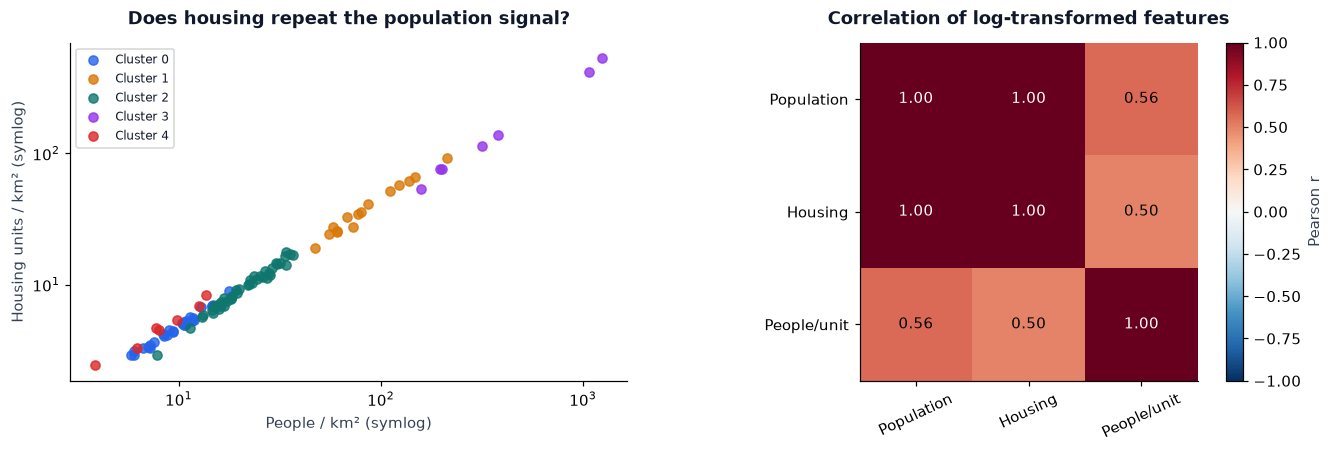

In [7]:
from cognition import style_plots, COLORS
import matplotlib.pyplot as plt
style_plots()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for group in sorted(gdf.cluster.unique()):
    part = gdf[gdf.cluster == group]
    axes[0].scatter(part.population_density, part.housing_density,
                    label=f"Cluster {group}", color=COLORS[int(group)], alpha=.8)
axes[0].set(xscale="symlog", yscale="symlog", xlabel="People / km² (symlog)",
            ylabel="Housing units / km² (symlog)", title="Does housing repeat the population signal?")
axes[0].legend(fontsize=8)
corr = X.corr()
im = axes[1].imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
axes[1].set_xticks(range(3), ["Population", "Housing", "People/unit"], rotation=25)
axes[1].set_yticks(range(3), ["Population", "Housing", "People/unit"])
for r in range(3):
    for c in range(3):
        axes[1].text(c, r, f"{corr.iloc[r,c]:.2f}", ha="center", va="center",
                     color="white" if abs(corr.iloc[r,c]) > .65 else "black")
axes[1].set_title("Correlation of log-transformed features")
fig.colorbar(im, ax=axes[1], label="Pearson r")
plt.show()

**Challenge:** rerun K-Means with four clusters. Which counties move, and does that mean their actual population changed? Explain why these associations do not establish causes.